# Laboratorio 4 - avances 1 al 4

Ejecuta las celdas de arriba hacia abajo. El script de cianobacteria se aplica en Copernicus Browser; este notebook descarga las bandas y produce los índices numéricos para el análisis temporal.

In [4]:
import openeo

con = openeo.connect('https://openeo.dataspace.copernicus.eu')
con.authenticate_oidc()
print(con.describe_collection('SENTINEL2_L2A')['title'])
print('Conexion y autenticacion listas.')

Authenticated using refresh token.
Sentinel-2 L2A
Conexion y autenticacion listas.


In [5]:
from datetime import date, timedelta
from pathlib import Path

LAGOS = {
    'atitlan': {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979},
    'amatitlan': {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799},
}

FECHAS = {
    'atitlan': ['2025-01-18', '2025-04-13', '2025-05-13', '2025-07-17', '2025-11-21', '2025-12-29', '2026-02-12', '2026-03-24', '2026-04-13', '2026-04-28', '2026-07-22'],
    'amatitlan': ['2025-01-28', '2025-04-15', '2025-04-28', '2025-11-24', '2026-01-08', '2026-02-02', '2026-02-07', '2026-03-29', '2026-04-13', '2026-04-28', '2026-06-19'],
}

# NDVI/NDWI usan B03, B04 y B08. B05 permite NDCI; las otras bandas soportan el script de cianobacteria.
BANDAS = ['B02', 'B03', 'B04', 'B05', 'B07', 'B8A', 'B08', 'B11', 'B12']
PROYECTO_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == 'l04_analisis_geoespacial'), Path.cwd() / 'l04_analisis_geoespacial')
DATA_DIR = PROYECTO_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
def descargar_escena(lago, fecha):
    inicio = date.fromisoformat(fecha)
    fin = inicio + timedelta(days=1)
    salida = DATA_DIR / lago / f'{fecha}_bandas.tif'
    salida.parent.mkdir(parents=True, exist_ok=True)
    if salida.exists():
        print(f'Ya existe: {salida}')
        return salida

    cubo = con.load_collection(
        'SENTINEL2_L2A',
        spatial_extent=LAGOS[lago],
        temporal_extent=[inicio.isoformat(), fin.isoformat()],
        bands=BANDAS,
        max_cloud_cover=20,
    )
    cubo.download(str(salida), format='GTiff')
    print(f'Descargado: {salida}')
    return salida

# Prueba primero una escena por lago. Si funciona, ejecuta el bucle de la celda siguiente.
descargar_escena('atitlan', '2026-04-13')
descargar_escena('amatitlan', '2026-04-13')

Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2026-04-13_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\amatitlan\2026-04-13_bandas.tif


WindowsPath('c:/Projects/Data-Science/l04_analisis_geoespacial/data/amatitlan/2026-04-13_bandas.tif')

In [7]:
# Descomenta solo despues de que la prueba anterior funcione.
for lago, fechas in FECHAS.items():
     for fecha in fechas:
         descargar_escena(lago, fecha)

Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2025-01-18_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2025-04-13_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2025-05-13_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2025-07-17_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2025-11-21_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2025-12-29_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2026-02-12_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2026-03-24_bandas.tif
Ya existe: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2026-04-13_bandas.tif
Descargado: c:\Projects\Data-Science\l04_analisis_geoespacial\data\atitlan\2026-04-28_bandas.tif
Descargado: c:\Projects\Data-Sc

In [8]:
import numpy as np
import pandas as pd
import rasterio

def indice_seguro(numerador, denominador):
    return np.divide(numerador, denominador, out=np.full(numerador.shape, np.nan, dtype='float32'), where=denominador != 0)

def calcular_indices(ruta):
    with rasterio.open(ruta) as src:
        if src.count != len(BANDAS):
            raise ValueError(f'{ruta} tiene {src.count} bandas; descarga de nuevo con las {len(BANDAS)} bandas de BANDAS.')
        datos = src.read().astype('float32') * 0.0001
        bandas = {nombre: datos[i] for i, nombre in enumerate(BANDAS)}

    ndvi = indice_seguro(bandas['B08'] - bandas['B04'], bandas['B08'] + bandas['B04'])
    ndwi = indice_seguro(bandas['B03'] - bandas['B08'], bandas['B03'] + bandas['B08'])
    ndci = indice_seguro(bandas['B05'] - bandas['B04'], bandas['B05'] + bandas['B04'])
    clorofila_a = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071

    # Solo agua: evita promediar tierra. Ajustable tras comparar con el mapa del Browser.
    agua = ndwi > 0.0
    return ndvi, ndwi, ndci, np.where(agua, clorofila_a, np.nan)

_, _, _, ciano_prueba = calcular_indices(DATA_DIR / 'atitlan' / '2026-04-13_bandas.tif')
print('Promedio preliminar Atitlan 2026-04-13:', np.nanmean(ciano_prueba))

Promedio preliminar Atitlan 2026-04-13: -19.859276


In [9]:
resultados = []
for lago, fechas in FECHAS.items():
    for fecha in fechas:
        ruta = DATA_DIR / lago / f'{fecha}_bandas.tif'
        if not ruta.exists():
            continue
        ndvi, ndwi, ndci, ciano = calcular_indices(ruta)
        resultados.append({
            'lago': lago, 'fecha': fecha,
            'cianobacteria_promedio': float(np.nanmean(ciano)),
            'ndvi_promedio': float(np.nanmean(np.where(ndwi > 0, ndvi, np.nan))),
            'ndwi_promedio': float(np.nanmean(np.where(ndwi > 0, ndwi, np.nan))),
        })

serie = pd.DataFrame(resultados)
serie['fecha'] = pd.to_datetime(serie['fecha'])
serie.to_csv(DATA_DIR / 'serie_temporal_preliminar.csv', index=False)
serie.sort_values(['lago', 'fecha'])

,lago,fecha,cianobacteria_promedio,ndvi_promedio,ndwi_promedio
11,amatitlan,2025-01-28,14.648438,-0.348515,0.567648
12,amatitlan,2025-04-15,7.788650,-0.089627,0.274265
13,amatitlan,2025-04-28,11.258584,-0.061094,0.275332
14,amatitlan,2025-11-24,10.439149,-0.371451,0.508388
15,amatitlan,2026-01-08,15.624824,-0.133844,0.382397
16,amatitlan,2026-02-02,5.912590,-0.063519,0.173864
17,amatitlan,2026-02-07,-158.336609,-0.601476,0.699084
18,amatitlan,2026-03-29,12.993173,-0.071051,0.297529
19,amatitlan,2026-04-13,15.774342,-0.026850,0.267751
20,amatitlan,2026-04-28,15.655456,-0.044492,0.306143


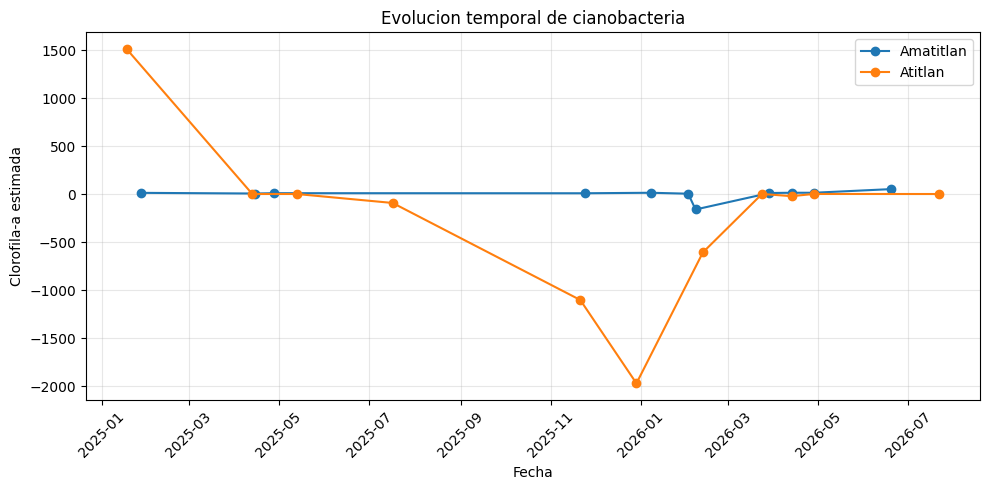

,lago,fecha,cianobacteria_promedio
21,amatitlan,2026-06-19,53.425510
0,atitlan,2025-01-18,1511.308228


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for lago, grupo in serie.groupby('lago'):
    grupo = grupo.sort_values('fecha')
    ax.plot(grupo['fecha'], grupo['cianobacteria_promedio'], marker='o', label=lago.title())
ax.set(title='Evolucion temporal de cianobacteria', xlabel='Fecha', ylabel='Clorofila-a estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

serie.loc[serie.groupby('lago')['cianobacteria_promedio'].idxmax(), ['lago', 'fecha', 'cianobacteria_promedio']]